# Star Tracker CNN

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import random, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import label, center_of_mass

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {device}")

PyTorch : 2.5.1+cu121
CUDA    : True
Device  : cuda


Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 37.0 MB/s eta 0:01:07
     ---------------------------------------- 0.0/2.4 GB 41.2 MB/s eta 0:01:00
     ---------------------------------------- 0.0/2.4 GB 42.5 MB/s eta 0:00:58
      --------------------------------------- 0.0/2.4 GB 43.0 MB/s eta 0:00:57
      --------------------------------------- 0.0/2.4 GB 42.7 MB/s eta 0:00:57
      --------------------------------------- 0.1/2.4 GB 42.9 MB/s eta 0:00:56
     - -------------------------------------- 0.1/2.4 GB 43.1 MB/s eta 0:00:56
     - -------------------------------------- 0.1/2.4 GB 43.4 MB/s eta 0:00:55
     - -------------------------------------- 0.1/2.4 GB 43.4 MB/s eta 0:00:55
     - -------------------------------------- 0.1/2.4 GB 43.7 MB/s eta 0:00:55
     - -------------------------------------- 0.1/2.4 GB 43.5 MB/s eta 0:00:55
 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install astropy astroquery tqdm scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import random, time, warnings
import numpy as np
from pathlib import Path
from scipy.ndimage import gaussian_filter, label
from tqdm import tqdm
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.skyview import SkyView

warnings.filterwarnings('ignore')

In [5]:
random.seed(42)
def download_image(ra, dec):
    coord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')
    try:
        result = SkyView.get_images(position=coord, survey=['DSS2 Red'],
                                    pixels='256',
                                    width=6.0*u.arcmin,
                                    height=6.0*u.arcmin)
    except:
        return None
    if not result:
        return None
    img = result[0][0].data.squeeze().astype('float32')
    p1, p99 = np.percentile(img, 1), np.percentile(img, 99)
    if p99 <= p1:
        return None
    return np.clip((img - p1) / (p99 - p1), 0, 1)

In [6]:
def make_seg(image):
    smoothed   = gaussian_filter(image, sigma=1.0)
    binary     = (smoothed > 0.55).astype('int32')
    labeled, n = label(binary)
    H, W       = image.shape
    Y, X       = np.ogrid[:H, :W]
    seg        = np.zeros((H, W), dtype='float32')
    for i in range(1, n + 1):
        mask = labeled == i
        if mask.sum() < 3 or mask.sum() > 80:
            continue
        ys, xs = np.where(mask)
        cy, cx = ys.mean(), xs.mean()
        seg[np.sqrt((X - cx)**2 + (Y - cy)**2) <= 3] = 1.0
    return seg

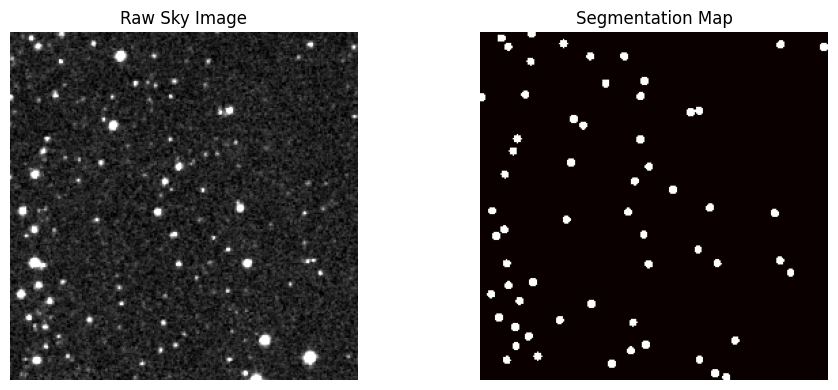

In [7]:
def show_sample(idx=0):
    img = np.load(f'data/train/image_{idx:04d}.npy')
    seg = np.load(f'data/train/seg_{idx:04d}.npy')

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img, cmap='gray', origin='lower')
    axes[0].set_title('Raw Sky Image')
    axes[0].axis('off')
    axes[1].imshow(seg, cmap='hot', origin='lower')
    axes[1].set_title('Segmentation Map')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

show_sample(0)